# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

1. **Множество $S_1 = \{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$** - **выпукло**.  
   *Обоснование:* Функция $f(x_1) = x_1^2$ выпукла на $\mathbb{R}$, так как её вторая производная $f''(x_1) = 2 > 0$ всюду неотрицательна. Множество $S_1$ по определению является надграфиком ($\operatorname{epi} f$) этой функции:
   $$\operatorname{epi} f = \{(x_1, x_2) \in \mathbb{R}^2 : x_2 \ge f(x_1)\}.$$
   По теореме из раздела 3 конспекта, надграфик функции выпукл тогда и только тогда, когда сама функция выпукла. Следовательно, множество $S_1$ выпукло.

2. **Множество $S_2 = \{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при любых $A \in \mathbb{R}^{m \times n}, b \in \mathbb{R}^m$** - **выпукло**.  
   *Обоснование:* Евклидова норма $\Vert \cdot \Vert_2$ выпукла в силу неравенства треугольника и положительной однородности. Композиция выпуклой функции с аффинным отображением $x \mapsto Ax - b$ сохраняет выпуклость (раздел 5 конспекта), поэтому функция $g(x) = \Vert Ax - b\Vert_2$ выпукла на $\mathbb{R}^n$. Множество $S_2 = \{x : g(x) \le 1\}$ представляет собой подуровневое множество выпуклой функции, а любое подуровневое множество выпуклой функции выпукло.  
   *(Эквивалентное геометрическое обоснование: $S_2$ является аффинным прообразом замкнутого единичного шара $\{y \in \mathbb{R}^m : \Vert y\Vert_2 \le 1\}$, а аффинный прообраз выпуклого множества всегда выпукл).*

3. Множество $\{x\in\mathbb R^2:\|x\|_2\geq1\}$ **не выпукло**. Точки $x=(1,0)$ и $y=(-1,0)$ принадлежат ему, но их середина $(x+y)/2=(0,0)$ не принадлежит, поскольку её норма равна нулю.

**(б)**

1. Для $f(x)=x_1^2+a x_1x_2+x_2^2$ гессиан постоянен:
   $$\nabla^2 f=\begin{pmatrix}2 & a \\ a & 2\end{pmatrix}.$$
   Его собственные числа равны $2-a$ и $2+a$. Поэтому $\nabla^2f\succeq0$ тогда и только тогда, когда $|a|\leq2$, а $\nabla^2f\succ0$ — когда $|a|<2$. Следовательно, функция выпукла при $|a|\leq2$ и строго выпукла при $|a|<2$. При $a=\pm2$ одно собственное число равно нулю, поэтому строгой выпуклости нет.

2. Для $g(x)=x_1^2x_2^2$
   $$\nabla^2g(x)=\begin{pmatrix}2x_2^2 & 4x_1x_2 \\ 4x_1x_2 & 2x_1^2\end{pmatrix},\qquad \det\nabla^2g=-12x_1^2x_2^2.$$
   Если $x_1x_2\ne0$, определитель отрицателен, то есть гессиан индефинитен. Например, в точке $(1,1)$ его собственные числа равны $-2$ и $6$. Поэтому $g$ не выпукла на $\mathbb R^2$.

In [4]:
# ваш код
a_values = np.array([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])

print("Проверка собственных чисел гессиана f:")
for a_value in a_values:
    hessian = np.array([[2.0, a_value], [a_value, 2.0]])
    eigenvalues = np.linalg.eigvalsh(hessian)
    print(f"a = {a_value:>4.1f}: eigenvalues = {eigenvalues}")

hessian_g_at_11 = np.array([[2.0, 4.0], [4.0, 2.0]])
print("\nСобственные числа гессиана g в точке (1, 1):",
      np.linalg.eigvalsh(hessian_g_at_11))

Проверка собственных чисел гессиана f:
a = -3.0: eigenvalues = [-1.  5.]
a = -2.0: eigenvalues = [0. 4.]
a = -1.0: eigenvalues = [1. 3.]
a =  0.0: eigenvalues = [2. 2.]
a =  1.0: eigenvalues = [1. 3.]
a =  2.0: eigenvalues = [0. 4.]
a =  3.0: eigenvalues = [-1.  5.]

Собственные числа гессиана g в точке (1, 1): [-2.  6.]


**(в)**

1. **$f(x) = \|Ax - b\|_2 + \lambda \|x\|_\infty$, $\lambda \ge 0$** - **выпукла**.  
   *Обоснование:* 
   * Евклидова норма $\|y\|_2$ и чебышёвская норма $\|x\|_\infty = \max_i |x_i|$ выпуклы по определению нормы.
   * Первое слагаемое $\|Ax - b\|_2$ выпукло как композиция евклидовой нормы с аффинным выражением $Ax - b$.
   * Второе слагаемое $\lambda \|x\|_\infty$ выпукло как умножение выпуклой нормы на неотрицательное число $\lambda \ge 0$.
   * Сумма двух выпуклых функций выпукла, поэтому вся функция $f(x)$ выпукла.  
   *Гладкость:* **Негладкая** из-за изломов нормы $\|x\|_\infty$ и точки $Ax - b = 0$, где евклидова норма недифференцируема.

2. **$f(x) = \max_{i} (a_i^\top x - b_i)^2$** - **выпукла**.  
   *Обоснование:* Для каждого $i$ функция $h_i(x) = (a_i^\top x - b_i)^2$ дважды дифференцируема, а её гессиан $\nabla^2 h_i(x) = 2 a_i a_i^\top \succeq 0$ положительно полуопределен при всех $x$, следовательно, каждая из функций $h_i(x)$ выпукла. Целевая функция $f(x) = \max_i h_i(x)$ представляет собой поточечный максимум конечного числа выпуклых функций, а операция взятия максимума сохраняет выпуклость (операция 3 раздела 5).  
   *Гладкость:* **Негладкая** в точках, где максимум одновременно достигается на нескольких индексах с несовпадающими градиентами (образуются изломы).

3. **$f(x) = e^{-\Vert x\Vert_2^2}$** - **не выпукла**.  
   *Обоснование:* Правило композиции $g(h(x))$ из раздела 5 конспекта требует, чтобы внешняя функция $g(u) = e^{-u}$ была выпуклой и *неубывающей*. В данном случае функция $g(u) = e^{-u}$ строго убывает, поэтому теорема о композиции не применима.  
   *Контрпример:* Рассмотрим одномерный срез функции вдоль прямой: $\varphi(t) = e^{-t^2}$. Вторая производная:
   $$\varphi''(t) = (4t^2 - 2) e^{-t^2}.$$
   При $|t| < \frac{1}{\sqrt{2}}$ производная $\varphi''(t) < 0$ (в частности, $\varphi''(0) = -2 < 0$), то есть в окрестности нуля функция строго вогнута. Возьмем точки $x_1 = (-1, 0, \dots, 0)^\top$ и $x_2 = (1, 0, \dots, 0)^\top$. В них $f(x_1) = f(x_2) = e^{-1} \approx 0.368$. Значение хорды в середине отрезка ($t = 0.5$, $x = 0$) равно $e^{-1} \approx 0.368$, однако значение функции в середине $f(0) = 1 > 0.368$. Хорда лежит строго под графиком, что противоречит определению выпуклой функции.  
   *Гладкость:* **Гладкая** ($C^\infty$) на всем $\mathbb{R}^n$.

**(г)**

* **(а) Ближайшая точка прямой:** **выпукла**.  
  Целевая функция $f(x) = \Vert x - p\Vert_2^2$ квадратичная с $\nabla^2 f(x) = 2I \succ 0$ (строго выпукла). Ограничения-равенства $x_1 + x_2 + x_3 - 1 = 0$ и $x_1 - x_3 = 0$ аффинны, ограничений-неравенств нет.
* **(б) Задача о диете:** **выпукла**.  
  Целевая функция $c^\top x$ линейна (выпукла). Равенства отсутствуют. Ограничения-неравенства $Ax - b \ge 0$ и $x \ge 0$ задаются аффинными функциями, которые являются вогнутыми, формируя выпуклый многогранник допустимых планов.
* **(в) Вписанный прямоугольник наибольшей площади:** **невыпукла**.  
  Ограничение-равенство $x_1^2 + x_2^2 - 1 = 0$ нелинейно, что прямо нарушает пункт 2 чек-листа и делает допустимое множество (дугу окружности) невыпуклым. *(Кроме того, цель $-4x_1 x_2$ имеет знакопеременный гессиан с собственными числами $\pm 4$ и не является выпуклой).*
* **(г) Подгонка синусоиды $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$:** **невыпукла**.  
  Целевая функция $f(x) = \sum_{i=1}^N (x_1 \sin(x_2 t_i + x_3) - y_i)^2$ мультимодальна и невыпукла: из-за нелинейного тригонометрического вхождения параметров $x_2$ и $x_3$ матрица Гессе в широких областях пространства параметров имеет отрицательные собственные числа, а сама задача имеет бесконечно много изолированных локальных минимумов.
* **(д, бонус) Чебышёвская подгонка:** **выпукла**.  
  В расширенном пространстве $(x, t) \in \mathbb{R}^{n+1}$ целевая функция $f(x, t) = t$ линейна. Ограничения $t - (a_i^\top x - b_i) \ge 0$ и $t + (a_i^\top x - b_i) \ge 0$ линейны (аффинны, вогнуты), что строго соответствует чек-листу выпуклой LP.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [5]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

Для $f(x)=\tfrac12\|x-p\|_2^2$ имеем $\nabla f(x)=x-p$.

Сначала покажем, что $x^*$ лежит на границе полупространства. Если бы $a^\top x^*<b$, то при достаточно малом $\varepsilon>0$ точка
$$y=x^*+\varepsilon(p-x^*)$$
оставалась бы допустимой. Но тогда
$$\nabla f(x^*)^\top(y-x^*)=(x^*-p)^\top\varepsilon(p-x^*)=-\varepsilon\|p-x^*\|_2^2<0,$$
что противоречит условию оптимальности. Следовательно, $a^\top x^*=b$.

Пусть $v$ — любой вектор, для которого $a^\top v=0$. Точки $y=x^*+v$ и $y=x^*-v$ лежат на границе и допустимы. Подстановка обеих точек в условие оптимальности даёт
$$ (x^*-p)^\top v\geq0,\qquad -(x^*-p)^\top v\geq0,$$
поэтому $(x^*-p)^\top v=0$ для всех $v\perp a$. Значит, $x^*-p$ параллелен $a$. Запишем $x^*=p-\mu a$. Из граничного равенства следует
$$a^\top p-\mu\|a\|_2^2=b,\qquad \mu=\frac{a^\top p-b}{\|a\|_2^2}>0.$$
Таким образом,
$$\boxed{x^*=p-\frac{a^\top p-b}{\|a\|_2^2}a}.$$

Осталось проверить достаточное условие. Для любого допустимого $y$
$$\nabla f(x^*)^\top(y-x^*)=(-\mu a)^\top(y-x^*)=\mu(b-a^\top y)\geq0.$$
Цель и множество выпуклы, поэтому по теореме это действительно единственная проекция.

**Численная проверка (пункты 2 и 3)**

In [9]:
# ваш код
def projection_objective(x):
    return 0.5 * np.sum((x - p) ** 2)


def projection_gradient(x):
    return x - p


mu = (a @ p - b) / (a @ a)
x_formula = p - mu * a

constraint = {
    "type": "ineq",
    "fun": lambda x: b - a @ x,
    "jac": lambda x: -a,
}
result = minimize(
    projection_objective,
    x0=np.zeros(3),
    jac=projection_gradient,
    method="SLSQP",
    constraints=constraint,
    options={"ftol": 1e-12, "maxiter": 1000},
)

print("Проекция по формуле:  ", x_formula)
print("Проекция через SLSQP: ", result.x)
print("Норма разности:       ", np.linalg.norm(result.x - x_formula))
print("a^T x* - b:           ", a @ x_formula - b)


candidates = rng.normal(size=(6000, 3))
feasible_points = candidates[candidates @ a <= b][:2000]
assert len(feasible_points) == 2000

values_at_optimum = (x_formula - p) @ (feasible_points - x_formula).T
x_nonoptimal = np.zeros(3)
values_at_zero = (x_nonoptimal - p) @ (feasible_points - x_nonoptimal).T

print("\nМинимум скалярного произведения в x*: ", values_at_optimum.min())
print("Минимум скалярного произведения в x=0:", values_at_zero.min())

Проекция по формуле:   [ 2.41666667 -0.16666667  1.08333333]
Проекция через SLSQP:  [ 2.41666667 -0.16666667  1.08333333]
Норма разности:        0.0
a^T x* - b:            -4.440892098500626e-16

Минимум скалярного произведения в x*:  0.0028415957571567008
Минимум скалярного произведения в x=0: -8.344233828738991


По формуле получаем
$$x^*=\left(\frac{29}{12},-\frac16,\frac{13}{12}\right)^\top\approx(2.4167,-0.1667,1.0833)^\top.$$
Результат SLSQP совпадает с формулой с погрешностью порядка $10^{-15}$, а ограничение активно: $a^\top x^*=b$.

Для случайных допустимых точек минимум величины $\nabla f(x^*)^\top(y-x^*)$ неотрицателен (получилось небольшое положительное число, поскольку случайная выборка почти наверняка не содержит точку точно на граничной касательной плоскости). Это согласуется с оптимальностью $x^*$. Для допустимой, но неоптимальной точки $x=0$ минимум отрицателен: в выборке найдено допустимое направление, вдоль которого целевая функция убывает в первом порядке.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

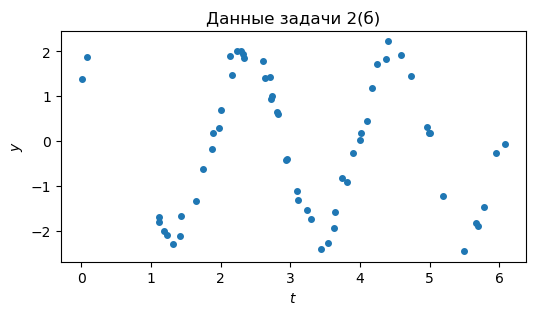

In [10]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Модель A** задаёт безусловную нелинейную задачу наименьших квадратов, то есть NLP. Она невыпукла: при фиксированных $x_1$ и $x_2$ целевая функция периодична по $x_3$ с периодом $2\pi$ и в общем случае не постоянна, тогда как непостоянная выпуклая функция на $\mathbb R$ не может быть периодической. Кроме того,
$$f(x_1,x_2,x_3)=f(x_1,x_2,x_3+2\pi)=f(-x_1,x_2,x_3+\pi),$$
поэтому одна и та же кривая имеет несколько разнесённых представлений параметров.

**Модель B** задаёт безусловную QP. Если
$$X=\begin{pmatrix}\sin(\omega t_1) & \cos(\omega t_1) \\ \vdots & \vdots \\ \sin(\omega t_N) & \cos(\omega t_N)\end{pmatrix},$$
то $f_B(x)=\tfrac12\|Xx-y\|_2^2$ и $\nabla^2f_B=X^\top X\succeq0$, так как $v^\top X^\top Xv=\|Xv\|_2^2\geq0$. Следовательно, задача выпукла. Для данных точек столбцы $X$ линейно независимы, поэтому $X^\top X\succ0$, цель строго выпукла, а решение единственно.

**Мультистарт (пункт 2)**

Итоговые f для модели A:
[ 1.139273 63.824891  1.139273  1.139273  1.139273 61.497273 61.497273
 64.251776  1.139273 63.824891  1.139273  1.139273 61.497273  1.139273
 64.251776  1.139273 61.688171  1.139273 61.497273  1.139273]
Доля стартов у лучшего найденного значения: 0.55
Лучшие параметры A: [ 2.10139254 -2.99669062 -3.84185661]

Итоговые f для модели B:
[1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764
 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764
 1.140764 1.140764 1.140764 1.140764]
Доля стартов у лучшего найденного значения: 1.00
Лучшие параметры B: [1.6234269  1.33780773]


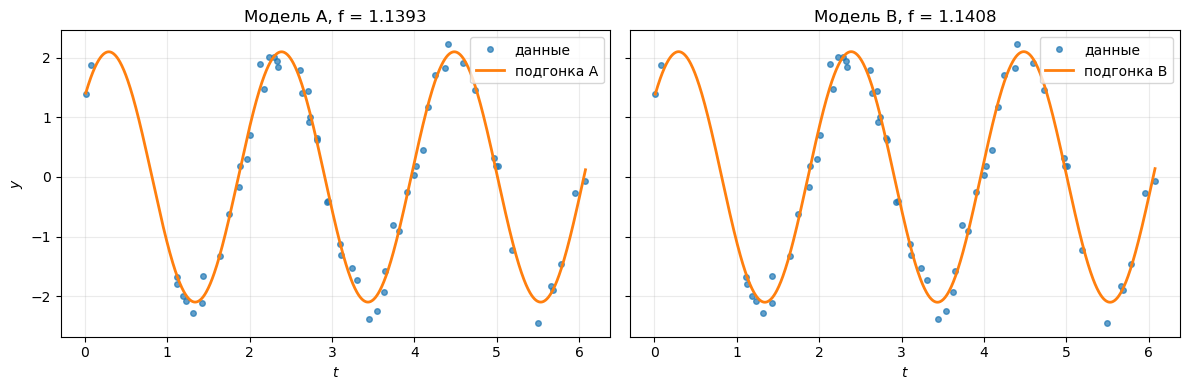

In [ ]:
def predict_a(x, time):
    return x[0] * np.sin(x[1] * time + x[2])


def objective_a(x):
    residual = predict_a(x, t) - y
    return 0.5 * residual @ residual


def gradient_a(x):
    z = x[1] * t + x[2]
    sine = np.sin(z)
    cosine = np.cos(z)
    residual = x[0] * sine - y
    return np.array([
        residual @ sine,
        residual @ (x[0] * cosine * t),
        residual @ (x[0] * cosine),
    ])


design_b = np.column_stack((np.sin(omega * t), np.cos(omega * t)))


def objective_b(x):
    residual = design_b @ x - y
    return 0.5 * residual @ residual


def gradient_b(x):
    return design_b.T @ (design_b @ x - y)


results_a = [
    minimize(objective_a, start, method="BFGS", jac=gradient_a,
             options={"gtol": 1e-8, "maxiter": 3000})
    for start in starts
]
results_b = [
    minimize(objective_b, start[:2], method="BFGS", jac=gradient_b,
             options={"gtol": 1e-8, "maxiter": 3000})
    for start in starts
]

values_a = np.array([result.fun for result in results_a])
values_b = np.array([result.fun for result in results_b])
best_a = results_a[np.argmin(values_a)]
best_b = results_b[np.argmin(values_b)]


reached_best_a = np.isclose(values_a, values_a.min(), rtol=1e-5, atol=1e-7)
reached_best_b = np.isclose(values_b, values_b.min(), rtol=1e-5, atol=1e-7)

print("Итоговые f для модели A:")
print(np.array2string(values_a, precision=6))
print(f"Доля стартов у лучшего найденного значения: {reached_best_a.mean():.2f}")
print("Лучшие параметры A:", best_a.x)

print("\nИтоговые f для модели B:")
print(np.array2string(values_b, precision=6))
print(f"Доля стартов у лучшего найденного значения: {reached_best_b.mean():.2f}")
print("Лучшие параметры B:", best_b.x)

t_dense = np.linspace(t.min(), t.max(), 1000)
prediction_a = predict_a(best_a.x, t_dense)
prediction_b = (best_b.x[0] * np.sin(omega * t_dense)
                + best_b.x[1] * np.cos(omega * t_dense))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(t, y, "o", ms=4, alpha=0.7, label="данные")
axes[0].plot(t_dense, prediction_a, lw=2, label="подгонка A")
axes[0].set_title(f"Модель A, f = {best_a.fun:.4f}")
axes[1].plot(t, y, "o", ms=4, alpha=0.7, label="данные")
axes[1].plot(t_dense, prediction_b, lw=2, label="подгонка B")
axes[1].set_title(f"Модель B, f = {best_b.fun:.4f}")
for axis in axes:
    axis.set_xlabel("$t$")
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel("$y$")
plt.tight_layout()
plt.show()

**Объяснение (пункт 3)**

Для выпуклой модели B любой локальный минимум глобален. Поскольку здесь цель строго выпукла, все 20 запусков приходят к одному решению и одному значению $f$. Для модели A главная теорема неприменима: разные старты попадают как в хорошее решение около истинной частоты, так и в локальные минимумы с существенно большими значениями функции. В данном запуске к наименьшему найденному значению пришли 55% стартов модели A и 100% стартов модели B.

Пусть решение модели B равно $(\beta_1,\beta_2)$. Из тождества
$$R\sin(\omega t+\phi)=R\cos\phi\sin(\omega t)+R\sin\phi\cos(\omega t)$$
получаем
$$R=\sqrt{\beta_1^2+\beta_2^2},\qquad \phi=\operatorname{atan2}(\beta_2,\beta_1).$$
Для найденного решения $R\approx2.104$, $\phi\approx0.689$ рад., что близко к истинным значениям $2$ и $0.7$.

Минимальное обучающее значение у A немного меньше, потому что модель дополнительно подбирает частоту: получилось $x_2\approx2.997$ вместо фиксированного $\omega=3$. Дополнительная степень свободы позволяет слегка подстроиться под шум. Однако это не делает задачу A лучше: она невыпукла, чувствительна к старту, вычислительно менее надёжна и потенциально сильнее переобучается. Небольшое уменьшение ошибки на обучающих данных само по себе не доказывает лучшую обобщающую способность.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

Обозначим $u=P(p)$, $v=P(q)$ и $d=u-v$. Условие оптимальности для проекции $p$ с пробной точкой $v\in\Omega$ даёт
$$ (u-p)^\top(v-u)\geq0 \quad\Longleftrightarrow\quad (u-p)^\top d\leq0. $$
Для проекции $q$ с пробной точкой $u\in\Omega$ получаем
$$ (v-q)^\top(u-v)\geq0 \quad\Longleftrightarrow\quad (v-q)^\top d\geq0. $$
Следовательно,
$$\big[(u-p)-(v-q)\big]^\top d\leq0.$$
Поскольку $(u-p)-(v-q)=d-(p-q)$, имеем
$$\|d\|_2^2\leq(p-q)^\top d\leq\|p-q\|_2\,\|d\|_2,$$
где последнее неравенство — неравенство Коши–Буняковского. Если $d\ne0$, делим на $\|d\|_2$ и получаем
$$\boxed{\|P(p)-P(q)\|_2\leq\|p-q\|_2}.$$
При $d=0$ утверждение очевидно.

In [13]:
bonus_rng = np.random.default_rng(2027)
number_of_pairs, dimension = 1000, 5
p_points = 3.0 * bonus_rng.standard_normal((number_of_pairs, dimension))
q_points = 3.0 * bonus_rng.standard_normal((number_of_pairs, dimension))


def project_ball(points):
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    return points / np.maximum(1.0, norms)


def check_nonexpansiveness(name, projected_p, projected_q):
    projected_distances = np.linalg.norm(projected_p - projected_q, axis=1)
    original_distances = np.linalg.norm(p_points - q_points, axis=1)
    violations = projected_distances - original_distances
    ratios = projected_distances / np.maximum(
        original_distances, np.finfo(float).eps
    )
    print(f"{name}: максимальное отношение = {ratios.max():.6f}, "
          f"максимальное нарушение = {violations.max():.3e}")
    assert np.all(violations <= 1e-12)


check_nonexpansiveness("Единичный шар",
                       project_ball(p_points), project_ball(q_points))
check_nonexpansiveness("Куб [-1, 1]^n",
                       np.clip(p_points, -1.0, 1.0),
                       np.clip(q_points, -1.0, 1.0))

Единичный шар: максимальное отношение = 0.386291, максимальное нарушение = -1.388e+00
Куб [-1, 1]^n: максимальное отношение = 0.893767, максимальное нарушение = -3.230e-01


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).